# Optimización de Portafolio — Modelo de Markowitz

Aplicación de la Teoría Moderna de Portafolios (Markowitz, 1952) a tres acciones del IPSA: **COPEC**, **FALABELLA** y **CMPC** (Mayo 2024 – Mayo 2026).

El objetivo es encontrar la combinación óptima de pesos que maximice el Sharpe ratio y trazar la frontera eficiente completa usando dos enfoques: simulación de Monte Carlo y optimización analítica con scipy.

In [72]:
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize as sop

## 1. Carga de datos

Se descargan 2 años de precios de cierre diarios para las tres acciones usando Yahoo Finance. Se calculan los retornos diarios y la matriz de covarianza — insumos fundamentales del modelo.

In [73]:
lista_nombres = ["COPEC.SN", "FALABELLA.SN", "CMPC.SN"]
brutos = yf.download(tickers = lista_nombres, period= "2y")
valores_cierre = brutos["Close"]

[*********************100%***********************]  3 of 3 completed


In [74]:
retornos_diarios = valores_cierre.pct_change()
vector_pesos = np.array([0.1, 0.1, 0.8])

In [75]:
retornos_medios = retornos_diarios.mean()
retorno_portafolio = np.dot(retornos_medios, vector_pesos)
print(retorno_portafolio)

0.0011784115873921916


In [76]:
covarianza_portafolio = retornos_diarios.cov()
covarianza_portafolio


Ticker,CMPC.SN,COPEC.SN,FALABELLA.SN
Ticker,,,
CMPC.SN,0.000295,0.000143,0.000111
COPEC.SN,0.000143,0.000225,0.000088
FALABELLA.SN,0.000111,0.000088,0.000285


## 2. Función de evaluación de portafolio

Para cualquier vector de pesos `w`, se calcula:
- **Retorno esperado:** `w · retornos_medios` (producto punto)
- **Varianza:** `w^T · Cov · w` (producto matricial)
- **Volatilidad:** raíz cuadrada de la varianza
- **Sharpe simplificado:** retorno / volatilidad

In [77]:
varianza = np.dot(vector_pesos, np.dot(covarianza_portafolio, vector_pesos))
dst = np.sqrt(varianza)
print(dst)
sharpe = retorno_portafolio/dst
print(sharpe)

0.01491229333833237
0.07902282772047271


In [78]:
pesosgrandes = np.random.random(3)
pesos = pesosgrandes/pesosgrandes.sum()

## 3. Simulación de Monte Carlo

Se generan 10.000 portafolios con pesos aleatorios (normalizados para que sumen 1). Para cada uno se calcula retorno, volatilidad y Sharpe. El portafolio de máximo Sharpe es el último tras ordenar por Sharpe.

In [79]:
def funcion_definicon(pesos):
    vector_pesos = np.array([pesos[0], pesos[1], pesos[2]])
    retorno_portafolio = np.dot(retornos_medios, vector_pesos)
    varianza = np.dot(vector_pesos, np.dot(covarianza_portafolio, vector_pesos))
    dst = np.sqrt(varianza)
    sharpe = retorno_portafolio/dst
    return [sharpe, retorno_portafolio, dst, pesos]

In [80]:
resultadosfinales = []
for i in range(10000):
    pesosgrandes = np.random.random(3)
    pesos = pesosgrandes/pesosgrandes.sum()
    resultadocadapeso = funcion_definicon(pesos)
    resultadosfinales.append(resultadocadapeso)
resultadosfinales.sort()
print(resultadosfinales)

[[np.float64(-0.054264438797588986), np.float64(-0.0009131058244469636), np.float64(0.01682696522215823), array([0.96171284, 0.029399  , 0.00888816])], [np.float64(-0.054210334049869024), np.float64(-0.0009169003797361559), np.float64(0.01691375631245296), array([0.97227839, 0.01650841, 0.0112132 ])], [np.float64(-0.05392104299171784), np.float64(-0.0008981609217741553), np.float64(0.01665696492391868), array([0.94159903, 0.04968973, 0.00871124])], [np.float64(-0.05258359704180568), np.float64(-0.000877878587134828), np.float64(0.01669491317676282), array([0.94933539, 0.02755947, 0.02310514])], [np.float64(-0.052578664220005185), np.float64(-0.0008612421081350152), np.float64(0.016380068244627045), array([0.90980635, 0.07444446, 0.01574919])], [np.float64(-0.052491556805139394), np.float64(-0.0008396126945726431), np.float64(0.015995195145182616), array([0.85714913, 0.1371936 , 0.00565727])], [np.float64(-0.05226668035913921), np.float64(-0.0008644380345951484), np.float64(0.0165389886

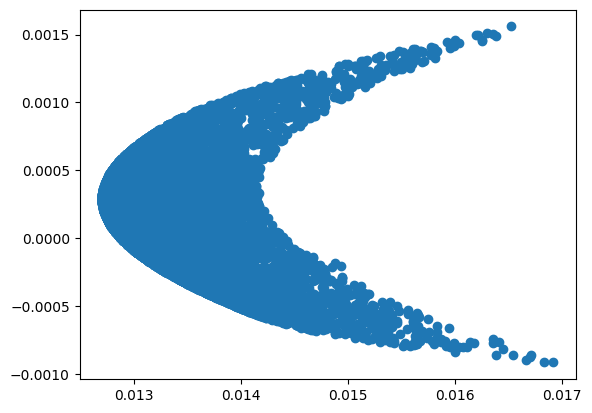

In [81]:
retornos = [r[1] for r in resultadosfinales]
volatilidades = [r[2] for r in resultadosfinales]
plt.scatter(volatilidades, retornos)

In [82]:
mejor = resultadosfinales[-1]
print("Sharpe:", mejor[0])
print("Retorno:", mejor[1])
print("Volatilidad:", mejor[2])
print("Pesos:", mejor[3])


Sharpe: 0.09437489453642052
Retorno: 0.0015591555315900122
Volatilidad: 0.01652087177685071
Pesos: [0.00126902 0.03043088 0.9683001 ]


In [83]:
def sharpe_negativo(pesos):
    return -(funcion_definicon(pesos)[0])

## 4. Optimización analítica — Máximo Sharpe

En vez de adivinar con 10.000 portafolios, `scipy.optimize.minimize` encuentra el óptimo exacto. Se minimiza el Sharpe negativo (equivalente a maximizar el Sharpe) sujeto a: pesos suman 1, cada peso entre 0 y 1.

In [84]:
sop.minimize(sharpe_negativo,
            x0 = [1/3, 1/3, 1/3],
            constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1},
            bounds=[(0, 1), (0, 1), (0, 1)]
        )

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -0.09581597251592577
           x: [ 2.523e-17  0.000e+00  1.000e+00]
         nit: 5
         jac: [ 9.422e-02  4.132e-02  9.313e-10]
        nfev: 20
        njev: 5
 multipliers: [ 4.132e-02]

In [85]:
def funcion_dst(pesos):
    vector_pesos = np.array([pesos[0], pesos[1], pesos[2]])
    return np.sqrt(np.dot(vector_pesos, np.dot(covarianza_portafolio, vector_pesos)))

## 5. Frontera eficiente completa

Para cada nivel de retorno posible (50 valores entre el mínimo y máximo), se minimiza la volatilidad del portafolio. El resultado es la frontera eficiente analítica — la curva que ningún portafolio puede cruzar hacia la izquierda.

El gráfico superpone la nube de Monte Carlo (azul) con la frontera analítica (naranja).

In [86]:
posibles_retornos = np.linspace(np.dot(retornos_medios, [1, 0, 0]), np.dot(retornos_medios, [0, 0, 1]), 50)
lista_mejores_pesos_por_cada_retorno = []
for i in posibles_retornos:
    resultado = sop.minimize(funcion_dst,
             x0 = [1,0,0],
             constraints=[{'type':'eq', 'fun':lambda w: w.sum() - 1},
                           {'type':'eq', 'fun': lambda w: np.dot(retornos_medios, w) - i}],
             bounds = [(0, 1), (0, 1), (0, 1)])
    lista_mejores_pesos_por_cada_retorno.append([i, resultado.fun, resultado.x])

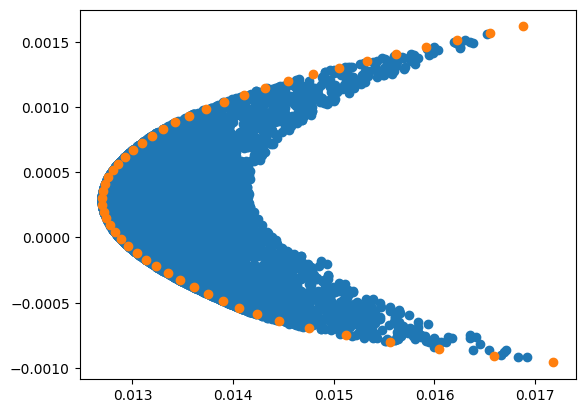

In [87]:
volatilidad = [r[1] for r in lista_mejores_pesos_por_cada_retorno]
retorno = [r[0] for r in lista_mejores_pesos_por_cada_retorno]
plt.scatter(volatilidades, retornos)
plt.scatter(volatilidad, retorno)